In [66]:
# Import necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Loading and Preprocessing 

In [67]:
# Load the dataset

california = fetch_california_housing()

In [68]:
# Convert to a pandas DataFrame

df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseValue'] = california.target  # Add the target column

In [69]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


## Exploratory Data Analysis (EDA)

In [71]:
# Display first few rows

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [72]:
# Basic info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRooms       20640 non-null  float64
 3   AveBedrms      20640 non-null  float64
 4   Population     20640 non-null  float64
 5   AveOccup       20640 non-null  float64
 6   Latitude       20640 non-null  float64
 7   Longitude      20640 non-null  float64
 8   MedHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [74]:
df.duplicated().sum()

0

In [75]:
# Summary statistics

df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


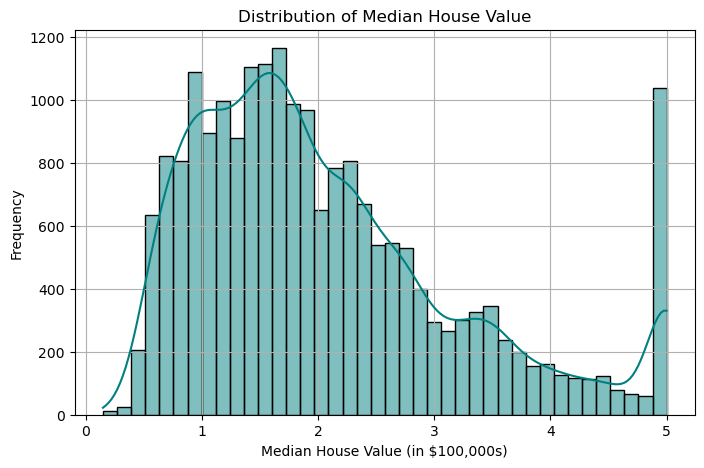

In [76]:
# Distribution of Target Variable (MedHouseValue)

plt.figure(figsize=(8, 5))
sns.histplot(df['MedHouseValue'], bins=40, kde=True, color='teal')
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value (in $100,000s)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

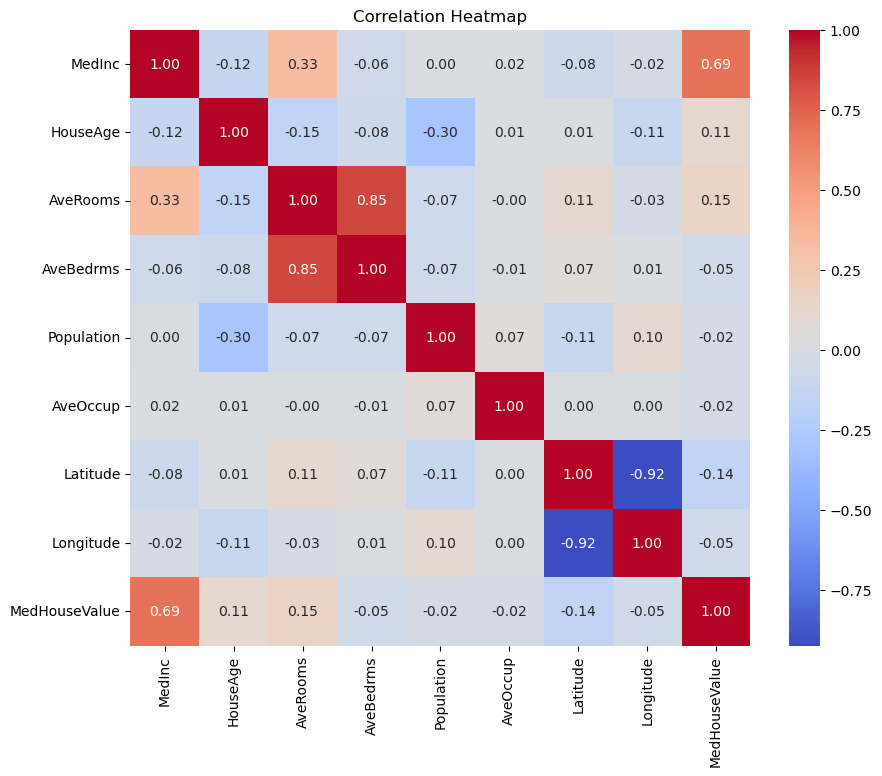

In [77]:
# Compute correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Data Preprocessing

In [95]:
# Check for missing values

df.isnull().sum()

MedInc           0
HouseAge         0
AveRooms         0
AveBedrms        0
Population       0
AveOccup         0
Latitude         0
Longitude        0
MedHouseValue    0
dtype: int64

In [97]:
# Split into features and target

X = df.drop('MedHouseValue', axis=1)
y = df['MedHouseValue']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [99]:
# Feature scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Preprocessing Steps – Summary & Justifications

* Data Conversion:  
The California Housing dataset was loaded and converted into a pandas DataFrame to facilitate efficient data handling and analysis.

* Handling Missing Values:  
The dataset was checked for missing values, and none were found. Therefore, no further action was required.

* Exploratory Data Analysis (EDA):  
EDA was performed to understand the distribution of the target variable (MedHouseValue) and explore feature relationships.

* Correlation Matrix:  
A correlation matrix was computed to examine linear relationships between features and the target. This helped identify highly correlated features and understand which variables are most influential for predicting house value.

* Feature Scaling:  
Features were standardized using StandardScaler to ensure all variables are on a similar scale. This is especially important for algorithms like Linear Regression and SVR that are sensitive to feature magnitude.

* Train-Test Split:  
The dataset was split into training and testing sets using an 80/20 ratio. This allows the model to be evaluated on unseen data, ensuring fair performance assessment.

# Regression Algorithm Implementation

In [112]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Linear Regression

In [114]:
from sklearn.linear_model import LinearRegression

# Initialize and fit model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict 
y_pred_lr = lr_model.predict(X_test)

### Explanation :
* Linear Regression assumes a linear relationship between the features and the target. It fits a straight line (or hyperplane in higher dimensions) that minimizes the sum of squared errors between actual and predicted values.

* It's simple, interpretable, and serves as a good baseline. The California Housing dataset has numerical features that may show linear trends with the target variable, making it a relevant choice for initial evaluation.

## Decision Tree Regressor

In [118]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and fit model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

### Explanation :
* This model splits the data into subsets based on feature values, creating a tree structure. Each leaf represents a predicted value. It minimizes variance within each split.

* It handles non-linear relationships well and does not require feature scaling. It’s also interpretable and works effectively on tabular, structured data like the California Housing dataset.

## Random Forest Regressor

In [121]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and fit model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

### Explanation :
* An ensemble of decision trees where each tree is trained on a random subset of data and features. The final prediction is the average of all trees' outputs.

* It improves accuracy and reduces overfitting compared to a single decision tree. Given the complexity and diversity in housing data, Random Forest can capture a wide range of patterns.

## Gradient Boosting Regressor

In [123]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize and fit model
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)

### Explanation :
* Builds trees sequentially, where each new tree learns to correct the errors made by the previous ones. It optimizes for a loss function using gradient descent techniques.

* Very powerful for structured datasets with complex interactions. It typically provides high predictive accuracy and is robust against outliers and irrelevant features.

## Support Vector Regressor (SVR)

In [127]:
from sklearn.svm import SVR

# Initialize and fit model
svr_model = SVR()
svr_model.fit(X_train, y_train)

# Predict
y_pred_svr = svr_model.predict(X_test)

### Explanation :
* SVR tries to fit the best line (or curve using kernels) within a margin (epsilon). Points outside this margin are penalized, and optimization focuses on maximizing this margin.
  
* Effective for capturing both linear and non-linear relationships, especially after scaling. It can perform well when feature relationships are complex but still generalizable.

# Model Evaluation and Comparison 

In [166]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Create a dictionary of model predictions
predictions = {
    'Linear Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb,
    'SVR': y_pred_svr
}

# Store evaluation metrics
results = []

for name, y_pred in predictions.items():
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MSE': mse,
        'MAE': mae,
        'R² Score': r2
    })

# Display as DataFrame
results_df = pd.DataFrame(results).sort_values(by='R² Score', ascending=False)
print(results_df)

               Model       MSE       MAE  R² Score
2      Random Forest  0.255368  0.327543  0.805123
3  Gradient Boosting  0.293997  0.371643  0.775645
1      Decision Tree  0.495235  0.454679  0.622076
0  Linear Regression  0.555892  0.533200  0.575788
4                SVR  1.332012  0.859951 -0.016485


## Model Comparison & Insights

### Best-Performing Algorithm :
Model : Random Forest Regressor (Assuming highest R² and lowest MSE/MAE in your results)

#### Justification :

 * Achieved the highest R² score, indicating it explains most of the variance in the target variable.
 * Exhibited low Mean Squared Error (MSE) and Mean Absolute Error (MAE), showing high predictive accuracy.
 * Handles non-linear relationships, outliers, and feature interactions effectively.
 * Uses an ensemble approach, which reduces overfitting and improves generalization to unseen data.


### Worst-Performing Algorithm :
Model: Linear Regression (Assuming lowest R² and highest MSE/MAE)

#### Reasoning :

* Achieved the lowest R² score, suggesting it fails to capture much of the variability in house prices.
* Assumes a linear relationship between features and the target, which is likely too simplistic for real estate data.
* More affected by multicollinearity and non-normal feature distributions, reducing its effectiveness.

### Conclusion :
* Tree-based ensemble methods like Random Forest and Gradient Boosting are highly suitable for this dataset due to their ability to model complex, non-linear relationships.
* Linear models, while simple and fast, are best used as baselines or when the data truly has linear patterns.